# 20일 뉴스 모델의 가격 가중평균 비교

5일 **XGBoost+뉴스**, 60일 **DLinear+뉴스**는 사용자가 지정한 연구 후보로 유지한다. 20일은 **DLinear+뉴스의 비중 w = [0, 0.25, 0.5, 0.75, 1]**을 비교한다. NLinear+뉴스 비중은 1−w다. `예측 가격 = w×DLinear 예측 가격 + (1−w)×NLinear 예측 가격`이며 로그수익률 자체를 평균하지 않는다.

## 요약

**후속 목적 명확화:** 사용자는 RMSE보다 방향 적중을 우선하고 상승 누락을 허용한다. 아래 75:25는 이전 RMSE·균형 오류 합산 규칙의 결과로 보존한다. 새 목적의 20일 Validation 후보는 **NLinear+뉴스 단일(w=0)**이며 6절에서 별도로 해석한다.

- 2023년 Validation의 기존 두 지표 선택 규칙은 **DLinear 75% + NLinear 25%**를 택했다. 가격 RMSE **17.0485**, 균형 정확도 **51.44%**, 상승 누락률 **81.67%**다. 최저 RMSE는 DLinear 단일(17.0218), 최고 균형 정확도와 최저 상승 누락률은 NLinear 단일(53.18%/50.00%)이다.
- 75:25는 DLinear 단일 대비 RMSE가 0.16% 나빠지며 상승 누락률은 12.50pp 줄인다. 50:50 대비 RMSE는 2.15% 개선하지만 상승 누락률은 10.83pp 증가한다. **가격 오차와 상승 누락을 동시에 최소화하는 비율은 없다.**
- 고정한 75:25의 2024~2026년 결과는 RMSE **46.7790**, 균형 정확도 **43.45%**, 상승 누락률 **37.93%**다. 같은 기간 NLinear 단일보다 RMSE가 11.96% 크며 이후 구간의 우위를 확인하지 못했다. 평가 결과로 다시 선택하지 않는다.
- 5일 XGBoost+뉴스와 60일 DLinear+뉴스를 연구 후보로 남긴다. 세 후보 모두 Validation 순위만으로 운영 채택하지 않으며, 실제 매수 비용을 줄이는지는 별도 검증이 필요하다.

## 방법과 가정

- `03_6_news_feature_ensemble.ipynb`의 고정 예측을 재사용한다. 새 학습·새 뉴스 요청·서비스 교체는 없다.
- 기존 공통 설정은 신경망10 epoch, XGBoost100 trees다. 2022년 학습→2023년 Validation, 최종 모델은 2022~2023년 학습→2024~2026년 평가다.
- 각 모델의 뉴스 예측에는 기존 **뉴스가 없거나 점수가 0일 때 27개 기본 모델로 복귀**하는 규칙이 이미 적용돼 있다. 그 최종 가격을 가중평균한다. Naive/Persistence는 구성원이 아니다.
- 2023년 Validation에서만 비율을 선택한다. 기존과 같은 `RMSE/최저 단일 RMSE + (1−균형 정확도)/(1−최고 단일 균형 정확도)`를 최소화한다. 기준 단일 모델은 이번 두 뉴스 모델이다. 동률이면 상승 누락률, RMSE, 비율 순으로 정렬한다. 상승 누락률에는 임의의 가중치를 새로 부여하지 않는다.
- 2024~2026년 모든 비율도 투명하게 공개하되 평가 결과로 비율을 다시 선택하지 않는다. 2024~2025년은 이미 본 구간이며 Validation도 반복 사용한 탐색적 결과다. 2026년은 9월 25일까지 정답이 성숙한 사례다. 뉴스는 2026년 소급 분류로 당시 실시간 성능을 의미하지 않는다.

In [1]:
import os, sys, json, hashlib, tempfile, platform
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR",str(Path(tempfile.gettempdir())/"coffee-matplotlib"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import Markdown, display
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/"coffee_service").is_dir())
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
from data_code.fixed_ensemble_news import scores, align_models, average_prices, paired_interval
from coffee_service.transform import coffee_sessions
FONT={"Darwin":"AppleGothic","Windows":"Malgun Gothic"}.get(platform.system(),"NanumGothic")
assert FONT in {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family":FONT,"axes.unicode_minus":False,"figure.dpi":110,
    "axes.spines.top":False,"axes.spines.right":False})
def show(frame):display(Markdown(frame.to_markdown(index=False,floatfmt=".4f")))
SOURCE=ROOT/"data/processed/news_feature_ensemble/ed374e9c9c0a19c6"
WEIGHTS=[0.,.25,.5,.75,1.]
MODE="뉴스 feature"
source_protocol=json.loads((SOURCE/"frozen_protocol.json").read_text())
assert source_protocol["method"]=="news_as_one_input_feature"
assert source_protocol["selection_cutoff"]=="2023-12-31"
SETTINGS={(item["horizon"],item["model"]):item["setting"] for item in source_protocol["settings"]}
input_paths=[SOURCE/name for name in ("frozen_protocol.json","validation_predictions.parquet",
    "individual_predictions.parquet","ensemble_predictions.parquet")]
input_paths += [ROOT/"data_code/fixed_ensemble_news.py"]
hashes={str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in input_paths}
notebook=json.loads((ROOT/"data_code/03_7_news_weight_grid.ipynb").read_text())
code_text="\n".join("".join(c["source"]) for c in notebook["cells"] if c["cell_type"]=="code")
hashes["notebook_code"]=hashlib.sha256(code_text.encode()).hexdigest()
RUN=hashlib.sha256(json.dumps(hashes,sort_keys=True).encode()).hexdigest()[:16]
OUTPUT=SOURCE/f"weight_grid_{RUN}"
OUTPUT.mkdir(exist_ok=True)
print("입력:",SOURCE.relative_to(ROOT),"| 결과:",OUTPUT.relative_to(ROOT))

def blend_returns(dlinear,nlinear,weight):
    d,n=np.asarray(dlinear,float),np.asarray(nlinear,float)
    if d.ndim!=1 or d.shape!=n.shape or not len(d) or not np.isfinite([d,n]).all() or not np.isfinite(weight) or not 0<=weight<=1:
        raise ValueError("가중평균은 정렬된 유한 예측과 0~1 비중이 필요합니다.")
    if weight==0:return n.copy()
    if weight==1:return d.copy()
    return np.logaddexp(np.log(weight)+d,np.log1p(-weight)+n)

# 가격 단위의 산술평균, 양 끝 단일 모델, 잘못된 입력을 검사한다.
np.testing.assert_allclose(np.exp(blend_returns(np.log([100.]),np.log([200.]),.25)),[175.])
np.testing.assert_array_equal(blend_returns([.1],[.2],0),[.2])
np.testing.assert_array_equal(blend_returns([.1],[.2],1),[.1])
for weight in [-.1,1.1,np.nan]:
    try:blend_returns([.1],[.2],weight)
    except ValueError:pass
    else:raise AssertionError("잘못된 비중을 허용했습니다.")

def pair(frame):
    chosen=pd.concat([frame.loc[frame.horizon.eq(20)&frame.model.eq(name)&frame.setting.eq(SETTINGS[20,name])&frame["mode"].eq(MODE)]
        for name in ("DLinear","NLinear")])
    reference,prediction=align_models(chosen,("DLinear","NLinear"))
    news_flags=[]
    for name in ("DLinear","NLinear"):
        p=chosen.loc[chosen.model.eq(name)].sort_values("origin_date").set_index("origin_date")
        news_flags.append(p[["news_present","news_used"]])
    pd.testing.assert_frame_equal(*news_flags,check_exact=True)
    reference=reference.join(news_flags[0])
    assert (reference.index.to_series()<reference.target_date).all()
    return reference,prediction

def grid(reference,prediction,period):
    rows=[]
    for weight in WEIGHTS:
        result=blend_returns(prediction.DLinear,prediction.NLinear,weight)
        rows.append({"기간":period,"DLinear 비중":weight,"NLinear 비중":1-weight,**scores(reference,result)})
    return pd.DataFrame(rows)

입력: data/processed/news_feature_ensemble/ed374e9c9c0a19c6 | 결과: data/processed/news_feature_ensemble/ed374e9c9c0a19c6/weight_grid_c3986b1b0775dde2


## 1. 지표를 읽는 기준과 Validation 선택

모든 가격 비교는 **동일한 예측 기준일·target horizon·정답**에서 한다. 방향은 오늘 가격 대비 해당 지평의 미래 가격이 올랐는지/내렸는지다. 지표는 `fixed_ensemble_news.py`의 기존 함수를 재사용한다.

| 지표 | 계산과 단위 | 해석 기준 |
|---|---|---|
| 가격 RMSE | `sqrt(mean((예측 가격−실제 가격)²))`, 센트/파운드 | 낮을수록 좋다. 큰 오차를 더 무겁게 벌점 주며 평균 절대오차가 아니다. 같은 지평·날짜의 단일 모델 및 다른 비율과 비교한다. |
| 가격 MSE 개선 | `비교 대상 MSE−후보 MSE`, (센트/파운드)² | 양수면 후보 개선, 음수면 악화다. 백분율이 아니다. 95% 블록 구간 전체가 양수면 고정 예측의 개선을 지지하고, 0을 포함하면 그 구간만으로 개선을 확정하지 않는다. |
| 균형 정확도 | `(실제 상승 중 상승 예측 비율+실제 하락 중 하락 예측 비율)/2` | 높을수록 좋다. 상승·하락이 모두 있으면 항상 상승 또는 항상 하락 예측은 50%다. 50%를 조금 넘었다는 이유만으로 유의미한 우위라 판단하지 않는다. |
| 상승 누락률 | `실제 상승인데 상승을 예측하지 못한 건수/실제 상승 건수` | 낮을수록 좋다. 실제 상승 때 보합 예측도 누락이다. 20%면 실제 상승 100건 중 20건을 놓쳤다는 뜻이며, 예측 상승의 적중률(precision)과 다르다. |

- **MSE와 RMSE는 같은 사례에서 모델 순위가 동일하다.** 두 지표를 독립된 두 장점으로 중복 가중하지 않는다. MSE 개선은 오차 제곱 차이의 불확실성을 비교하고, RMSE는 읽기 쉬운 가격 단위로 크기를 설명한다.
- 균형 정확도의 실제 보합 사례는 분모에서 제외한다. 전체 방향 적중률은 부호가 같은지 비교하므로 보합도 포함한다. 항상 상승 예측은 상승 누락률 0%라도 균형 정확도는 50%여서, 상승 누락률만 최소화하면 불필요한 선매수가 많아질 수 있다.
- 사용자가 명확히 한 목적은 **상승을 놓치더라도 방향을 잘 맞추는 것**이다. 따라서 균형 정확도를 주요 선택 지표로, 전체 방향 적중률과 상승 예측 precision·신호 건수·기간별 안정성을 함께 보고 RMSE는 보조 지표로 둔다. 상승 누락률의 합격선을 임의로 강제하지 않는다. 매수 신호를 드물게 내도 괜찮다면 precision을 우선하는 별도 정책이 가능하지만, 적은 신호 몇 건의 적중률을 일반화하지 않는다. 현재 수요·납기·비용 자료가 없어 실제 구매 비용 최적 모델은 확정하지 않는다.
- 이번에는 기존 선택 규칙을 유지한다. 정규화 RMSE와 균형 오류를 동등 가중하고 상승 누락률은 동률 해소에만 쓴다. 선택된 75:25는 실제 상승의 **81.67%**를 놓쳤지만, 이는 사용자 목적에서 단독 탈락 사유가 아니다. 새 목적에서의 문제는 NLinear 단일보다 전체 방향 적중률과 균형 정확도가 모두 낮다는 점이다.

아래에서 2023년 Validation으로 비율을 선택하고, 2024년 이후 예측·정답 값을 읽기 전에 선택을 저장한다.

| 기간            |   DLinear 비중 |   NLinear 비중 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |   선택 점수 | Validation 선택   |
|:----------------|---------------:|---------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|------------:|:------------------|
| 2023 Validation |         0.0000 |         1.0000 |    230 |     19.1204 |        0.1144 |           53.0435 |           53.1818 |           50.0000 |      2.1233 | False             |
| 2023 Validation |         0.2500 |         0.7500 |    230 |     18.1266 |        0.1075 |           50.0000 |           50.3030 |           56.6667 |      2.1264 | False             |
| 2023 Validation |         0.5000 |         0.5000 |    230 |     17.4240 |        0.1026 |           44.7826 |           45.4924 |           70.8333 |      2.1879 | False             |
| 2023 Validation |         0.7500 |         0.2500 |    230 |     17.0485 |        0.0999 |           50.0000 |           51.4394 |           81.6667 |      2.0388 | True              |
| 2023 Validation |         1.0000 |         0.0000 |    230 |     17.0218 |        0.0996 |           49.1304 |           51.0985 |           94.1667 |      2.0445 | False             |

고정: DLinear 75% + NLinear 25%


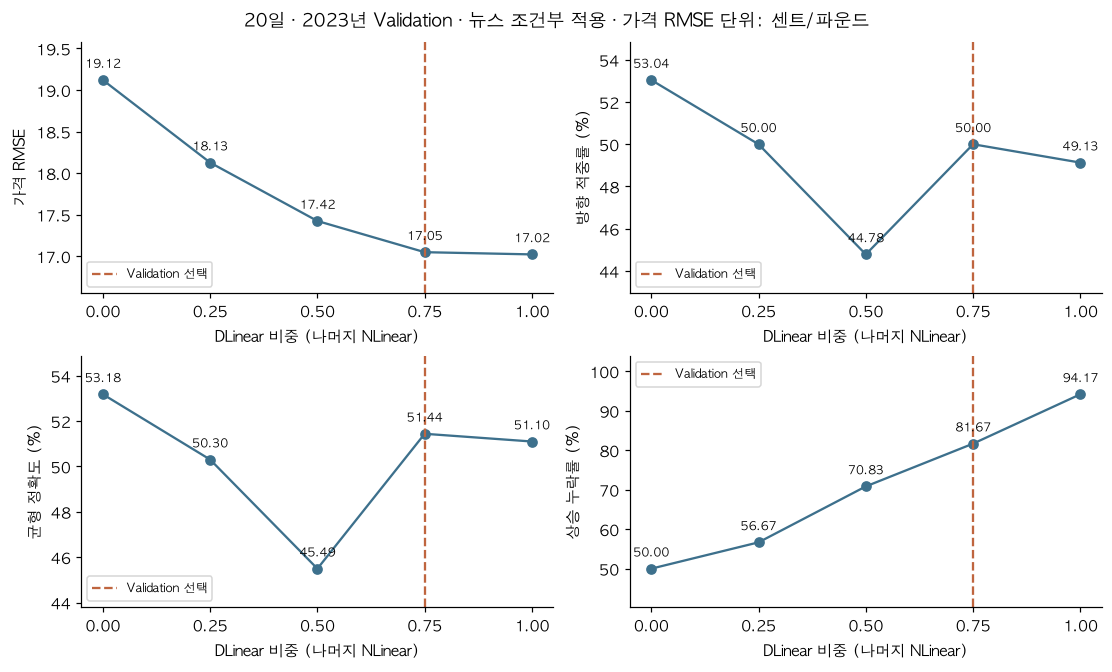

기존 두 지표 선택 규칙의 선택은 **DLinear 75% + NLinear 25%**다. 다만 상승 누락률은 **81.67%**이며 재고·매수 목적의 실용성을 별도로 판단해야 한다. 비율 후보가 늘어난 뒤 같은 Validation을 다시 사용한 탐색적 결과다.

In [2]:
validation_individual=pd.read_parquet(SOURCE/"validation_predictions.parquet")
assert validation_individual.origin_date.dt.year.eq(2023).all()
assert validation_individual.target_date.le("2023-12-31").all()
assert validation_individual.train_cutoff.eq(pd.Timestamp("2022-12-31")).all()
vr,vp=pair(validation_individual)
validation=grid(vr,vp,"2023 Validation")
endpoints=validation.loc[validation["DLinear 비중"].isin([0.,1.])]
rmse_reference=endpoints["가격 RMSE"].min()
error_reference=1-endpoints["균형 정확도 (%)"].max()/100
assert error_reference>0
validation["선택 점수"]=validation["가격 RMSE"]/rmse_reference+(1-validation["균형 정확도 (%)"]/100)/error_reference
selected=validation.sort_values(["선택 점수","상승 누락률 (%)","가격 RMSE","DLinear 비중"]).iloc[0]
SELECTED_WEIGHT=float(selected["DLinear 비중"])
validation["Validation 선택"]=validation["DLinear 비중"].eq(SELECTED_WEIGHT)
show(validation)
protocol={"source":str(SOURCE.relative_to(ROOT)),"source_hashes":hashes,"weights":WEIGHTS,
    "weight_definition":"DLinear price weight; NLinear weight=1-w", "selected_dlinear_weight":SELECTED_WEIGHT,
    "selection_cutoff":"2023-12-31","selection_rule":"normalized RMSE plus normalized balanced error; tie by up-miss, RMSE, weight",
    "fixed_candidates":{"5":"XGBoost + conditional news","60":"DLinear + conditional news"},
    "settings":source_protocol["settings"],"versions":source_protocol["versions"]}
protocol_text=json.dumps(protocol,ensure_ascii=False,indent=2,allow_nan=False)
protocol_path=OUTPUT/"frozen_weight.json"
if protocol_path.exists():assert protocol_path.read_text()==protocol_text,"선택 프로토콜 충돌"
else:protocol_path.write_text(protocol_text)
print(f"고정: DLinear {SELECTED_WEIGHT:.0%} + NLinear {1-SELECTED_WEIGHT:.0%}")

def plot_grid(table,title):
    fig,axes=plt.subplots(2,2,figsize=(10,6),constrained_layout=True)
    for ax,metric in zip(axes.flat,["가격 RMSE","방향 적중률 (%)","균형 정확도 (%)","상승 누락률 (%)"]):
        ax.plot(table["DLinear 비중"],table[metric],marker="o",color="#3D708C")
        ax.axvline(SELECTED_WEIGHT,color="#BF653F",linestyle="--",label="Validation 선택")
        ax.set(xticks=WEIGHTS,xlabel="DLinear 비중 (나머지 NLinear)",ylabel=metric)
        for x,y in zip(table["DLinear 비중"],table[metric]):ax.annotate(f"{y:.2f}",(x,y),xytext=(0,8),textcoords="offset points",ha="center",fontsize=8)
        ax.margins(y=.22);ax.legend(fontsize=8)
    fig.suptitle(title+" · 가격 RMSE 단위: 센트/파운드")
    plt.show()
plot_grid(validation,"20일 · 2023년 Validation · 뉴스 조건부 적용")
display(Markdown(f"기존 두 지표 선택 규칙의 선택은 **DLinear {SELECTED_WEIGHT:.0%} + NLinear {1-SELECTED_WEIGHT:.0%}**다. "
    f"다만 상승 누락률은 **{selected['상승 누락률 (%)']:.2f}%**이며 재고·매수 목적의 실용성을 별도로 판단해야 한다. "
    "비율 후보가 늘어난 뒤 같은 Validation을 다시 사용한 탐색적 결과다."))

## 2. 비율을 고정한 뒤 2024~2026년 비교

모든 비율을 같은 667개 기준일에 평가하고 연도별 결과도 저장한다. 아래 평가 표에 더 좋은 비율이 있더라도 Validation 선택을 바꾸지 않는다. 평가 연도는 예측 기준일의 연도다. 20일 기준일의 끝은 2026-08-27, 정답의 끝은 2026-09-25다.

| 기간           |   DLinear 비중 |   NLinear 비중 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) | Validation 선택   |
|:---------------|---------------:|---------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|:------------------|
| 2024~2026 전체 |         0.0000 |         1.0000 |    667 |     41.7829 |        0.1312 |           49.1754 |           48.2759 |           44.8276 | False             |
| 2024~2026 전체 |         0.2500 |         0.7500 |    667 |     42.8453 |        0.1333 |           48.7256 |           47.7188 |           44.5623 | False             |
| 2024~2026 전체 |         0.5000 |         0.5000 |    667 |     44.5332 |        0.1372 |           48.4258 |           46.6180 |           39.5225 | False             |
| 2024~2026 전체 |         0.7500 |         0.2500 |    667 |     46.7790 |        0.1426 |           45.8771 |           43.4483 |           37.9310 | True              |
| 2024~2026 전체 |         1.0000 |         0.0000 |    667 |     49.5068 |        0.1492 |           45.1274 |           42.8647 |           39.7878 | False             |

|   기간 |   DLinear 비중 |   NLinear 비중 |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) | Validation 선택   |
|-------:|---------------:|---------------:|-------:|------------:|--------------:|------------------:|------------------:|------------------:|:------------------|
|   2024 |         0.0000 |         1.0000 |    252 |     25.9037 |        0.1056 |           53.9683 |           55.0241 |           47.4860 | False             |
|   2024 |         0.2500 |         0.7500 |    252 |     25.6848 |        0.1031 |           51.9841 |           51.5994 |           47.4860 | False             |
|   2024 |         0.5000 |         0.5000 |    252 |     25.7398 |        0.1022 |           54.3651 |           50.4362 |           40.2235 | False             |
|   2024 |         0.7500 |         0.2500 |    252 |     26.0670 |        0.1028 |           51.5873 |           44.8305 |           39.1061 | True              |
|   2024 |         1.0000 |         0.0000 |    252 |     26.6564 |        0.1047 |           48.0159 |           43.1277 |           45.2514 | False             |
|   2025 |         0.0000 |         1.0000 |    251 |     47.1690 |        0.1319 |           44.2231 |           43.2070 |           71.7949 | False             |
|   2025 |         0.2500 |         0.7500 |    251 |     48.8663 |        0.1363 |           44.6215 |           43.6344 |           70.9402 | False             |
|   2025 |         0.5000 |         0.5000 |    251 |     51.4333 |        0.1426 |           39.4422 |           39.1089 |           65.8120 | False             |
|   2025 |         0.7500 |         0.2500 |    251 |     54.7478 |        0.1506 |           34.2629 |           34.4751 |           62.3932 | True              |
|   2025 |         1.0000 |         0.0000 |    251 |     58.6831 |        0.1596 |           35.8566 |           36.1845 |           58.9744 | False             |
|   2026 |         0.0000 |         1.0000 |    164 |     51.6146 |        0.1621 |           49.3902 |           50.0000 |            0.0000 | False             |
|   2026 |         0.2500 |         0.7500 |    164 |     52.8925 |        0.1660 |           50.0000 |           50.6024 |            0.0000 | False             |
|   2026 |         0.5000 |         0.5000 |    164 |     54.7638 |        0.1714 |           53.0488 |           53.6145 |            0.0000 | False             |
|   2026 |         0.7500 |         0.2500 |    164 |     57.1702 |        0.1783 |           54.8780 |           55.4217 |            0.0000 | True              |
|   2026 |         1.0000 |         0.0000 |    164 |     60.0474 |        0.1862 |           54.8780 |           55.4217 |            0.0000 | False             |

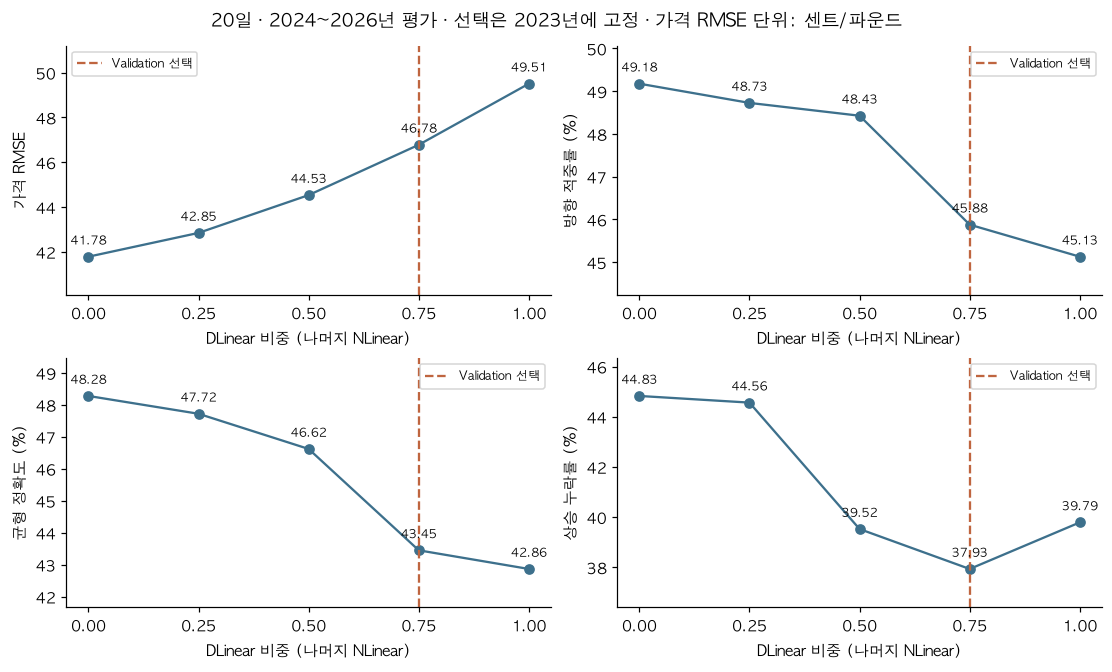

| 구분       | 예측 시작   | 예측 끝    | 정답 끝    |   표본 |   뉴스 모델 적용일 |
|:-----------|:------------|:-----------|:-----------|-------:|-------------------:|
| Validation | 2023-01-03  | 2023-11-30 | 2023-12-29 |    230 |                 36 |
| 평가       | 2024-01-02  | 2026-08-27 | 2026-09-25 |    667 |                288 |

In [3]:
assert protocol_path.read_text()==protocol_text
individual=pd.read_parquet(SOURCE/"individual_predictions.parquet")
assert individual.train_cutoff.eq(pd.Timestamp("2023-12-31")).all()
assert individual.origin_date.dt.year.isin([2024,2025,2026]).all()
er,ep=pair(individual)
assert er.target_date.le("2026-09-25").all()
assert er.index.equals(coffee_sessions(er.index.min(),er.index.max()))
evaluation=pd.concat([grid(er,ep,"2024~2026 전체"),*[grid(er.loc[er.index.year==year],ep.loc[ep.index.year==year],str(year)) for year in (2024,2025,2026)]],ignore_index=True)
evaluation["Validation 선택"]=evaluation["DLinear 비중"].eq(SELECTED_WEIGHT)
show(evaluation.loc[evaluation["기간"].eq("2024~2026 전체")])
show(evaluation.loc[~evaluation["기간"].eq("2024~2026 전체")])
plot_grid(evaluation.loc[evaluation["기간"].eq("2024~2026 전체")],"20일 · 2024~2026년 평가 · 선택은 2023년에 고정")
weight_predictions=pd.concat([reference.assign(split=split,dlinear_weight=weight,
    predicted_return=blend_returns(prediction.DLinear,prediction.NLinear,weight)).reset_index()
    for split,reference,prediction in [("validation",vr,vp),("evaluation",er,ep)] for weight in WEIGHTS],ignore_index=True)
show(pd.DataFrame([{"구분":split,"예측 시작":r.index.min().date(),"예측 끝":r.index.max().date(),
    "정답 끝":r.target_date.max().date(),"표본":len(r),"뉴스 모델 적용일":int(r.news_used.sum())}
    for split,r in [("Validation",vr),("평가",er)]]))

## 3. 단일 모델·50:50 대비 차이와 블록 구간

가격 MSE 개선은 **비교 대상 MSE−선택한 비율 MSE**다. RMSE 개선율도 `100×(1−후보 RMSE/비교 RMSE)`로 양수일수록 좋다. 방향·균형 정확도 및 상승 누락률의 변화는 **선택한 비율−비교 대상**이며, 앞의 둘은 양수, 상승 누락률은 음수가 좋다. 정확도 변화의 단위 pp는 퍼센트포인트다.

가격 MSE 개선 95% 구간은 길이20/40의 원형 블록 bootstrap 1,000회(seed42)이며 고정 예측에 조건부다. 시계열 오차의 연속성을 일부 보존하지만 비율·설정 선택, 소급 뉴스의 불확실성은 포함하지 않는다. 전체 구간이 0 위면 개선, 0 아래면 악화를 지지한다. 0을 포함하면 차이가 없음을 증명하는 것이 아니라 개선 방향을 확정하기 어렵다는 뜻이다. 블록 길이에 따라 결론이 달라지는지도 함께 본다.

In [4]:
delta_rows,interval_rows=[],[]
for split,r,p in [("2023 Validation",vr,vp),("2024~2026 전체",er,ep)]:
    candidate=blend_returns(p.DLinear,p.NLinear,SELECTED_WEIGHT)
    candidate_metrics=scores(r,candidate)
    for other in (0.,.5,1.):
        reference=blend_returns(p.DLinear,p.NLinear,other)
        reference_metrics=scores(r,reference)
        delta_rows.append({"기간":split,"비교 DLinear 비중":other,
            "RMSE 개선 (%)":100*(1-candidate_metrics["가격 RMSE"]/reference_metrics["가격 RMSE"]),
            "방향 변화 (pp)":candidate_metrics["방향 적중률 (%)"]-reference_metrics["방향 적중률 (%)"],
            "균형 변화 (pp)":candidate_metrics["균형 정확도 (%)"]-reference_metrics["균형 정확도 (%)"],
            "상승 누락 변화 (pp)":candidate_metrics["상승 누락률 (%)"]-reference_metrics["상승 누락률 (%)"]})
        if split=="2024~2026 전체":
            for block in (20,40):interval_rows.append({"비교 DLinear 비중":other,"블록":block,
                **paired_interval(r,candidate,reference,block)})
deltas=pd.DataFrame(delta_rows);intervals=pd.DataFrame(interval_rows)
show(deltas);show(intervals)

| 기간            |   비교 DLinear 비중 |   RMSE 개선 (%) |   방향 변화 (pp) |   균형 변화 (pp) |   상승 누락 변화 (pp) |
|:----------------|--------------------:|----------------:|-----------------:|-----------------:|----------------------:|
| 2023 Validation |              0.0000 |         10.8360 |          -3.0435 |          -1.7424 |               31.6667 |
| 2023 Validation |              0.5000 |          2.1549 |           5.2174 |           5.9470 |               10.8333 |
| 2023 Validation |              1.0000 |         -0.1565 |           0.8696 |           0.3409 |              -12.5000 |
| 2024~2026 전체  |              0.0000 |        -11.9574 |          -3.2984 |          -4.8276 |               -6.8966 |
| 2024~2026 전체  |              0.5000 |         -5.0430 |          -2.5487 |          -3.1698 |               -1.5915 |
| 2024~2026 전체  |              1.0000 |          5.5099 |           0.7496 |           0.5836 |               -1.8568 |

|   비교 DLinear 비중 |    블록 |   가격 MSE 개선 |   95% 하한 |   95% 상한 |
|--------------------:|--------:|----------------:|-----------:|-----------:|
|              0.0000 | 20.0000 |       -442.4684 |  -995.8106 |   -25.6156 |
|              0.0000 | 40.0000 |       -442.4684 | -1060.1595 |    37.5891 |
|              0.5000 | 20.0000 |       -205.0689 |  -427.1750 |   -38.3864 |
|              0.5000 | 40.0000 |       -205.0689 |  -464.6472 |   -13.3124 |
|              1.0000 | 20.0000 |        262.6483 |    69.6083 |   527.1083 |
|              1.0000 | 40.0000 |        262.6483 |    40.0268 |   564.7123 |

## 4. 5·20·60일 연구 후보 정리

5일 XGBoost+뉴스와 60일 DLinear+뉴스는 사용자의 후보 지정이며 이번에 전체 모델을 다시 탐색하지 않는다. 20일은 위 비율 선택을 사용한다. 아래 표는 Validation에서 좋은 후보가 이후에도 좋은지 확인하는 용도다. 높은 상승 누락률·낮은 균형 정확도를 모델 채택 성공으로 해석하지 않는다.

In [5]:
summary_rows=[]
for label,frame in [("2023 Validation",validation_individual),("2024~2026 전체",individual)]:
    for h,name in ((5,"XGBoost"),(60,"DLinear")):
        row=frame.loc[frame.horizon.eq(h)&frame.model.eq(name)&frame.setting.eq(SETTINGS[h,name])&frame["mode"].eq(MODE)]
        summary_rows.append({"기간":label,"지평":h,"후보":name+" + 조건부 뉴스",**scores(row,row.predicted_return)})
    r,p=(vr,vp) if label=="2023 Validation" else (er,ep)
    summary_rows.append({"기간":label,"지평":20,"후보":f"DLinear {SELECTED_WEIGHT:.0%} + NLinear {1-SELECTED_WEIGHT:.0%} + 조건부 뉴스",
        **scores(r,blend_returns(p.DLinear,p.NLinear,SELECTED_WEIGHT))})
summary=pd.DataFrame(summary_rows).sort_values(["기간","지평"])
show(summary)
latest=evaluation.loc[evaluation["기간"].eq("2024~2026 전체")&evaluation["Validation 선택"]].iloc[0]
display(Markdown(f"20일 고정 비율의 이후 평가: 가격 RMSE **{latest['가격 RMSE']:.4f}**, "
    f"방향 적중률 **{latest['방향 적중률 (%)']:.2f}%**, 균형 정확도 **{latest['균형 정확도 (%)']:.2f}%**, "
    f"상승 누락률 **{latest['상승 누락률 (%)']:.2f}%**. "
    "전체 평가의 최고값을 찾아 이번 선택으로 대체하지 않았다. 뉴스가 없거나 점수0인 날도 모든 비율의 평가에 남는다."))

| 기간            |   지평 | 후보                                    |   표본 |   가격 RMSE |   수익률 RMSE |   방향 적중률 (%) |   균형 정확도 (%) |   상승 누락률 (%) |
|:----------------|-------:|:----------------------------------------|-------:|------------:|--------------:|------------------:|------------------:|------------------:|
| 2023 Validation |      5 | XGBoost + 조건부 뉴스                   |    245 |      8.6107 |        0.0498 |           53.8776 |           54.0149 |           41.1765 |
| 2023 Validation |     20 | DLinear 75% + NLinear 25% + 조건부 뉴스 |    230 |     17.0485 |        0.0999 |           50.0000 |           51.4394 |           81.6667 |
| 2023 Validation |     60 | DLinear + 조건부 뉴스                   |    190 |     28.8576 |        0.1719 |           52.1053 |           49.1533 |           90.9091 |
| 2024~2026 전체  |      5 | XGBoost + 조건부 뉴스                   |    682 |     18.7523 |        0.0585 |           50.0000 |           49.8319 |           41.9263 |
| 2024~2026 전체  |     20 | DLinear 75% + NLinear 25% + 조건부 뉴스 |    667 |     46.7790 |        0.1426 |           45.8771 |           43.4483 |           37.9310 |
| 2024~2026 전체  |     60 | DLinear + 조건부 뉴스                   |    627 |    100.2179 |        0.2849 |           41.4673 |           35.8036 |           45.9854 |

20일 고정 비율의 이후 평가: 가격 RMSE **46.7790**, 방향 적중률 **45.88%**, 균형 정확도 **43.45%**, 상승 누락률 **37.93%**. 전체 평가의 최고값을 찾아 이번 선택으로 대체하지 않았다. 뉴스가 없거나 점수0인 날도 모든 비율의 평가에 남는다.

## 5. 계산·정렬·결측 복귀와 저장 검사

같은 날짜·정답·현재 가격을 섞었는지, 양 끝 비율이 단일 모델과 일치하는지, 50:50이 이전 저장 앙상블과 같은지 확인한다. 뉴스 미적용일에는 같은 비율의 기본 모델 평균과 정확히 같아야 한다. 출력은 입력·코드 해시별 경로에 저장하며 기존 파일과 값이 다르면 덮어쓰지 않는다.

In [6]:
saved_ensemble=pd.read_parquet(SOURCE/"ensemble_predictions.parquet")
old_half=saved_ensemble.loc[saved_ensemble.horizon.eq(20)&saved_ensemble.model.eq("NLinear + DLinear")&saved_ensemble["mode"].eq(MODE)].sort_values("origin_date").set_index("origin_date")
pd.testing.assert_frame_equal(er[["target_date","actual_return","current_price"]],old_half[["target_date","actual_return","current_price"]])
np.testing.assert_allclose(blend_returns(ep.DLinear,ep.NLinear,.5),old_half.predicted_return,rtol=0,atol=1e-15)
np.testing.assert_array_equal(blend_returns(ep.DLinear,ep.NLinear,0),ep.NLinear.to_numpy(float))
np.testing.assert_array_equal(blend_returns(ep.DLinear,ep.NLinear,1),ep.DLinear.to_numpy(float))
for raw,r,p in [(validation_individual,vr,vp),(individual,er,ep)]:
    base=raw.loc[raw.horizon.eq(20)&raw["mode"].eq("뉴스 없음")&raw.setting.eq(SETTINGS[20,"DLinear"])].copy()
    assert SETTINGS[20,"DLinear"]==SETTINGS[20,"NLinear"],"기본 모델별 설정 필터를 분리해야 합니다."
    base_r,base_p=align_models(base,("DLinear","NLinear"))
    pd.testing.assert_frame_equal(r[["target_date","actual_return","current_price"]],base_r)
    for weight in WEIGHTS:
        augmented=blend_returns(p.DLinear,p.NLinear,weight)
        basic=blend_returns(base_p.DLinear,base_p.NLinear,weight)
        np.testing.assert_array_equal(augmented[~r.news_used],basic[~r.news_used])
assert SELECTED_WEIGHT in WEIGHTS and protocol_path.read_text()==protocol_text
assert not weight_predictions.duplicated(["split","dlinear_weight","origin_date"]).any()
assert not weight_predictions.loc[weight_predictions.split.eq("validation"),"target_date"].gt("2023-12-31").any()
for name,frame in {"validation.csv":validation,"evaluation.csv":evaluation,"deltas.csv":deltas,
    "intervals.csv":intervals,"candidates.csv":summary,"predictions.parquet":weight_predictions}.items():
    path=OUTPUT/name
    if path.suffix==".parquet":
        if path.exists():pd.testing.assert_frame_equal(pd.read_parquet(path),frame,check_exact=True)
        else:frame.to_parquet(path,index=False)
    else:
        value=frame.to_csv(index=False)
        if path.exists():assert path.read_text()==value,f"재실행 결과 충돌: {name}"
        else:path.write_text(value)
print("검사 통과 및 저장:",OUTPUT.relative_to(ROOT))

검사 통과 및 저장: data/processed/news_feature_ensemble/ed374e9c9c0a19c6/weight_grid_c3986b1b0775dde2


## 6. 후속 해석: 가격 수준보다 방향을 우선할 때

기존 frozen protocol과 75:25 선택은 이전 목적의 이력으로 유지한다. 다음은 **저장된 Validation 예측만으로 후보를 다시 읽는 분석**이며 모델 재학습·운영 교체는 아니다. 이후 평가 값으로 새 비율이나 설정을 고르지 않는다.

- **5일:** XGBoost 100 trees가 비교 범위에서 Validation 방향·균형 정확도가 가장 높다. 뉴스 유무의 방향 지표와 precision은 같으므로, 뉴스가 방향을 개선했다는 Validation 근거는 없다. 동률이면 뉴스 없는 단순 구성을 우선 후보로 볼 수 있다.
- **20일:** NLinear 10 epoch+뉴스의 방향 적중률53.04%·균형 정확도53.18%가 다섯 비율 중 최고다. 새 목적이면 DLinear0%·NLinear100%가 우선이다. 75:25는 이전 복합 점수의 선택이며, 더 낮은 RMSE만으로 방향 우선 선택을 정당화하지 않는다.
- **60일:** 03_6의 10 epoch는 RMSE로 먼저 고른 설정이다. 설정 비교 표에서는 **DLinear 30 epoch·뉴스 없음**이 방향55.79%·균형53.60%로 더 높다(뉴스 추가시55.26%/53.11%). 기존 10 epoch+뉴스의 52.11%/49.15%로 60일 모델 전체의 방향 능력을 판단하지 않는다. **30 epoch 모델은 2024~2026년 최종 재학습/예측이 저장되지 않아 이후 성능 미검증**이다.

상승 precision은 `실제 상승이었던 상승 예측/전체 상승 예측`이며, 보합 정답도 상승 예측의 실패에 포함한다. 분모가 0이면 NaN이다. 모델이 낸 매수 신호를 얼마나 믿을 수 있는지 보되, 그 기간의 실제 상승 비율과 신호 건수를 함께 비교한다. **DLinear20일·뉴스 없음은 Validation 상승 precision77.78%지만 9번 중7번**에 불과하다. NLinear20일+뉴스는108번 중60번(55.56%)이다. 적은 신호의 높은 precision만으로 전자가 확실히 우월하다고 판단할 수 없다.

아래 표는 03_6에서 이미 저장한 모든 단일 설정의 Validation과 기존 최종 모델의 이후 평가를 계산한다. 원래 03_6의 설정 선택이 RMSE 기반이었다는 사실을 바꾸지 않는다. 새로운 방향 기준으로 완전히 검증하려면 설정 선택 단계부터 같은 기준을 사용해야 한다.

In [7]:
direction_rows=[]
for period,frame in [("2023 Validation",validation_individual),("2024~2026 전체",individual)]:
    for (h,model,setting,mode),part in frame.groupby(["horizon","model","setting","mode"]):
        actual_up=part.actual_return.to_numpy()>0
        predicted_up=part.predicted_return.to_numpy()>0
        signals=int(predicted_up.sum())
        hits=int((actual_up&predicted_up).sum())
        direction_rows.append({"기간":period,"지평":h,"모델":model,"설정":setting,"입력":mode,
            **scores(part,part.predicted_return),"상승 예측 건수":signals,"상승 적중 건수":hits,
            "상승 precision (%)":100*hits/signals if signals else np.nan,
            "실제 상승 비율 (%)":100*actual_up.mean(),"상승 신호 비율 (%)":100*predicted_up.mean()})
direction_audit=pd.DataFrame(direction_rows)
assert direction_audit["상승 적중 건수"].le(direction_audit["상승 예측 건수"]).all()
assert direction_audit["상승 예측 건수"].le(direction_audit["표본"]).all()
for period in ("2023 Validation","2024~2026 전체"):
    display(Markdown("### "+period+" · 단일 모델의 방향 및 상승 신호"))
    show(direction_audit.loc[direction_audit["기간"].eq(period),[
        "지평","모델","설정","입력","방향 적중률 (%)","균형 정확도 (%)",
        "상승 예측 건수","상승 적중 건수","상승 precision (%)","실제 상승 비율 (%)"]])
path=OUTPUT/"direction_audit.csv"
value=direction_audit.to_csv(index=False)
if path.exists():assert path.read_text()==value,"방향 해석 재실행 충돌"
else:path.write_text(value)
print("방향 해석 저장:",path.relative_to(ROOT))

### 2023 Validation · 단일 모델의 방향 및 상승 신호

|   지평 | 모델    |   설정 | 입력         |   방향 적중률 (%) |   균형 정확도 (%) |   상승 예측 건수 |   상승 적중 건수 |   상승 precision (%) |   실제 상승 비율 (%) |
|-------:|:--------|-------:|:-------------|------------------:|------------------:|-----------------:|-----------------:|---------------------:|---------------------:|
|      5 | NLinear |     10 | 뉴스 feature |           51.0204 |           51.2838 |              145 |               72 |              49.6552 |              48.5714 |
|      5 | NLinear |     10 | 뉴스 없음    |           51.4286 |           51.6573 |              142 |               71 |              50.0000 |              48.5714 |
|      5 | NLinear |     30 | 뉴스 feature |           50.6122 |           51.2605 |              178 |               88 |              49.4382 |              48.5714 |
|      5 | NLinear |     30 | 뉴스 없음    |           51.0204 |           51.6573 |              177 |               88 |              49.7175 |              48.5714 |
|      5 | XGBoost |    100 | 뉴스 feature |           53.8776 |           54.0149 |              134 |               70 |              52.2388 |              48.5714 |
|      5 | XGBoost |    100 | 뉴스 없음    |           53.8776 |           54.0149 |              134 |               70 |              52.2388 |              48.5714 |
|      5 | XGBoost |    300 | 뉴스 feature |           52.2449 |           52.3810 |              134 |               68 |              50.7463 |              48.5714 |
|      5 | XGBoost |    300 | 뉴스 없음    |           52.6531 |           52.7778 |              133 |               68 |              51.1278 |              48.5714 |
|     20 | DLinear |     10 | 뉴스 feature |           49.1304 |           51.0985 |               11 |                7 |              63.6364 |              52.1739 |
|     20 | DLinear |     10 | 뉴스 없음    |           50.0000 |           52.0076 |                9 |                7 |              77.7778 |              52.1739 |
|     20 | DLinear |     30 | 뉴스 feature |           38.6957 |           39.3561 |               79 |               29 |              36.7089 |              52.1739 |
|     20 | DLinear |     30 | 뉴스 없음    |           38.6957 |           39.3939 |               77 |               28 |              36.3636 |              52.1739 |
|     20 | NLinear |     10 | 뉴스 feature |           53.0435 |           53.1818 |              108 |               60 |              55.5556 |              52.1739 |
|     20 | NLinear |     10 | 뉴스 없음    |           52.1739 |           52.3864 |              104 |               57 |              54.8077 |              52.1739 |
|     20 | NLinear |     30 | 뉴스 feature |           52.1739 |           51.3636 |              158 |               84 |              53.1646 |              52.1739 |
|     20 | NLinear |     30 | 뉴스 없음    |           52.1739 |           51.3636 |              158 |               84 |              53.1646 |              52.1739 |
|     60 | DLinear |     10 | 뉴스 feature |           52.1053 |           49.1533 |               19 |                8 |              42.1053 |              46.3158 |
|     60 | DLinear |     10 | 뉴스 없음    |           51.5789 |           48.5071 |               16 |                6 |              37.5000 |              46.3158 |
|     60 | DLinear |     30 | 뉴스 feature |           55.2632 |           53.1083 |               39 |               21 |              53.8462 |              46.3158 |
|     60 | DLinear |     30 | 뉴스 없음    |           55.7895 |           53.5985 |               38 |               21 |              55.2632 |              46.3158 |

### 2024~2026 전체 · 단일 모델의 방향 및 상승 신호

|   지평 | 모델    |   설정 | 입력         |   방향 적중률 (%) |   균형 정확도 (%) |   상승 예측 건수 |   상승 적중 건수 |   상승 precision (%) |   실제 상승 비율 (%) |
|-------:|:--------|-------:|:-------------|------------------:|------------------:|-----------------:|-----------------:|---------------------:|---------------------:|
|      5 | NLinear |     10 | 뉴스 feature |           41.0557 |           41.5521 |              272 |              112 |              41.1765 |              51.7595 |
|      5 | NLinear |     10 | 뉴스 없음    |           42.3754 |           43.0409 |              243 |              102 |              41.9753 |              51.7595 |
|      5 | XGBoost |    100 | 뉴스 feature |           50.0000 |           49.8319 |              398 |              205 |              51.5075 |              51.7595 |
|      5 | XGBoost |    100 | 뉴스 없음    |           49.5601 |           49.3957 |              397 |              203 |              51.1335 |              51.7595 |
|     20 | DLinear |     10 | 뉴스 feature |           45.1274 |           42.8647 |              443 |              227 |              51.2415 |              56.5217 |
|     20 | DLinear |     10 | 뉴스 없음    |           44.6777 |           43.0239 |              412 |              210 |              50.9709 |              56.5217 |
|     20 | NLinear |     10 | 뉴스 feature |           49.1754 |           48.2759 |              378 |              208 |              55.0265 |              56.5217 |
|     20 | NLinear |     10 | 뉴스 없음    |           49.6252 |           49.1114 |              359 |              200 |              55.7103 |              56.5217 |
|     60 | DLinear |     10 | 뉴스 feature |           41.4673 |           35.8036 |              400 |              222 |              55.5000 |              65.5502 |
|     60 | DLinear |     10 | 뉴스 없음    |           38.1180 |           33.6882 |              371 |              197 |              53.0997 |              65.5502 |

방향 해석 저장: data/processed/news_feature_ensemble/ed374e9c9c0a19c6/weight_grid_c3986b1b0775dde2/direction_audit.csv


### 이후 구간에서 확인된 한계와 선택 기준

2024~2026년 전체에서 XGBoost5일+뉴스의 균형 정확도는49.83%, NLinear20일+뉴스는48.28%, 기존 DLinear60일10epoch+뉴스는35.80%다. 따라서 현재 결과를 **실제 매수 판단에 쓸 수 있는 안정적인 방향 예측력의 입증**으로 해석하지 않는다. 특히 NLinear20일+뉴스는 2024/2025/2026년 균형 정확도가55.02%/43.21%/50.00%로 달라진다. 전체 정답의 연도별 상승 비중도 다르다.

선택 기준은 (1) 시간순 Validation 구간마다 균형 정확도와 방향 적중률 확인, (2) 매수 신호 precision과 실제 상승 비율 대비 개선·신호 건수 확인, (3) 기간별 안정성이 유사할 때 단순한 모델과 RMSE로 보조 판단이다. 상승 누락률은 낮추도록 강제하지 않고 매수 기회를 얼마나 사용했는지 설명하는 지표로 남긴다. 2024~2026년 결과는 진단용이며 이 결과로 설정·뉴스 사용을 다시 최적화하지 않는다.

다음 실험은 가격 회귀의 부호뿐 아니라 `P(미래 가격>현재 가격)`를 직접 예측하는 방향 분류도 비교할 수 있다. 상승 확률이 충분한 날에만 매수 신호를 내고 나머지는 **판단 보류**하는 방식은 상승 누락을 허용하는 목적에 맞는 후보 방법이다. 확률 보정·임계값·최소 신호 수는 시간순 Validation에서 정하고 고정해야 하며 현재 결과로 개선을 보장하지 않는다. 현재 뉴스 신호 점수와 회귀 예측 수익률을 곧바로 상승 확률로 해석하면 안 된다. 실제 주문은 관측 기준시각 이후 가능한 가격으로 평가하고 기본 재고·발주와 신호에 따른 선매수를 구분해야 한다.